- 실습 기본 환경 설정 


In [1]:

# 예제 실행 및 시각화를 위한 공통 라이브러리 로딩

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib 시각화에서 한글 폰트 사용 설정
common.set_korean_plot_env()

# 재현성 보장을 위한 시드 고정
#   여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 
#   독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.
#   또한 같은 환경에서도 GPU를 사용하는 경우, 일부 연산의 비결정적 성질로 인해 실행시마다 결과가 조금씩 달라질 수 있다.
SEED = 42
common.set_seed(SEED)

# 실습 환경에 맞는 하드웨어 가속기 장치 객체
device = common.get_device()



CUDA를 사용합니다.


# 7-2 임베딩을 사용하는 순환 신경망 모델

본 노트북은 7-2 절 본문의 [코드 7-2] ~ [코드 7-5] 예제와 본문이 깃허브 노트북에 미룬 다음 항목들을 모두 포함한다.

- `[코드 7-2]` `nn.Embedding` 임베딩 계층 생성
- `[코드 7-3]` `OzWriter` 모델 정의 (임베딩 + LSTM + 완전 연결)
- 데이터 전처리 (오즈의 마법사 텍스트 정제 + 토큰화)
- `[코드 7-4]` `OzDataset` 클래스, 어휘 사전, 데이터로더
- `[코드 7-5]` 모델 학습 환경 (임베딩 차원, 은닉 크기, 옵티마이저)
- 학습 루프 + 학습 곡선 ([그림 7-7])
- 마중물 텍스트로부터 문장 생성 함수 ([표 7-1])
- 대조군 `OzRawWriter` (임베딩 미사용) 정의/학습 및 비교

> 소설 '오즈의 마법사' 텍스트는 깃허브 저장소 규약(§13.9)에 따라 `'../../data/wonderful_wizard_of_oz.txt'` 로 읽는다.

이번 절은 본문의 모델 9의 구현을 포함한다. 모델 9의 제시문은 다음과 같다.

> **모델 9. 오즈의 소설가**
>
> 6장에서는 소설 <오즈의 마법사>의 텍스트를 학습한 모델을 사용해 영어 문자열에 띄어쓰기를 추가해 보았다. 이번에는 <오즈의 마법사>의 텍스트를 학습해 L. 프랭크 바움처럼 소설을 쓰는 오즈의 소설가 모델을 만들어 본다.

## [코드 7-2] 임베딩 계층 생성

`nn.Embedding(num_embeddings, embedding_dim)` 으로 임베딩 계층을 생성한다. `embeddings.weight` 는 `(num_embeddings, embedding_dim)` 형태의 임베딩 행렬이다.

In [2]:
########################################################################################
# 코드 7-2 - 임베딩 계층 생성
########################################################################################

import torch.nn as nn

# 어휘 사전의 크기가 20일 때, 토큰을 크기 10의 임베딩 벡터로 인코딩하는 임베딩 계층
embeddings = nn.Embedding(num_embeddings=20, embedding_dim=10)
# 인자를 순서대로 지정한 nn.Embedding(20, 10)과 같음
# embeddings.weight: 임베딩 계층의 가중치 텐서 = 임베딩 행렬
print(embeddings.weight.shape)

torch.Size([20, 10])


임베딩 행렬의 각 행은 한 토큰에 대응하는 임베딩 벡터이다. 처음에는 무작위 값으로 초기화되며, 모델 학습 과정에서 손실 기반의 역전파로 최적화된다.

## [코드 7-3] 임베딩 계층을 사용하는 LSTM 모델

`OzWriter` 는 임베딩 계층 → LSTM 계층 → 완전 연결 계층으로 구성된다.
- 입력: `(B, S)` 형태의 토큰 고유 번호 텐서 (원-핫 인코딩 없음)
- 임베딩 후 형태: `(B, S, D)` (D = 임베딩 벡터의 크기)
- LSTM 출력: `(B, S, hidden_size)` — 마지막 위치 `[:, -1, :]` 만 사용
- 최종 출력: `(B, V)` 의 로짓 (V = 어휘 사전의 크기)

In [3]:
########################################################################################
# 코드 7-3 - 임베딩 계층을 사용하는 순환 신경망 모델
########################################################################################

# 소설을 학습해, 마중물 텍스트의 다음 토큰을 예측하는 순환 신경망 모델 클래스
#     임베딩 계층, LSTM 계층, 완전 연결 계층으로 구성
class OzWriter(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        # 임베딩 계층
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        # LSTM 계층: input_size는 임베딩 벡터의 크기(embedding_dim)를 사용
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        # 완전 연결 계층
        self.fc = nn.Linear(hidden_size, vocab_size)

# B: 배치 크기, S: 입력 샘플의 길이, D: 임베딩 벡터의 크기, V: 어휘 사전의 크기    
    def forward(self, x):               # 입력 x: (B, S)
        x = self.embeddings(x)          #      -> (B, S, D)
        x, _ = self.lstm(x)             #      -> (B, S, hidden_size)
        x = x[:, -1, :]                 #      -> (B, hidden_size)
        return self.fc(x)               #      -> (B, V)

## 참고 - 오즈의 마법사 텍스트 로딩과 전처리

본문은 "모든 알파벳을 소문자로 바꾼 뒤, 공백 문자·소문자 알파벳·쉼표·마침표·느낌표·물음표·아포스트로피를 제외한 모든 문자를 삭제" 한다고 안내한다. 토큰화 단계에서는 쉼표/마침표/느낌표/물음표를 별도 토큰으로 분리하고 아포스트로피는 단어를 구성하는 글자로 취급한다.

본문은 깃허브 노트북에 데이터 전처리 코드를 두므로, 본 노트북에서는 동일한 결과를 내도록 정규식으로 전처리한다.

In [4]:
# 참고 - 오즈의 마법사 텍스트 불러오기
#   소설 원문 텍스트의 앞 부분, 뒷 부분에 소설의 내용이 아닌 다른 내용이 포함되어 있음([연습 문제 6-11] 참조)
#   이번에는 이 부분을 제거하고 모델 학습에 사용함

import re
from pathlib import Path

raw = Path('../../data/wonderful_wizard_of_oz.txt').read_text(
    encoding='utf-8-sig',
)

# 본문 시작은 줄바꿈 뒤의 'Chapter I' 줄 패턴. 그 앞은 목차이므로 건너뜀.
match = re.search(r'\nChapter I\n', raw)
start = match.start() if match else raw.find('Chapter I')
end = raw.rfind('*** END OF THE PROJECT GUTENBERG')
if end == -1:
    end = raw.rfind('THE END')
text = raw[start:end].strip()
print(f'본문 길이: {len(text):,}자')
print(f'본문 시작 80자: {text[:80]!r}')

본문 길이: 205,490자
본문 시작 80자: 'Chapter I\nThe Cyclone\n\n\nDorothy lived in the midst of the great Kansas prairies,'


In [5]:
# 참고 - 텍스트 정제와 토큰화

# 1) 소문자 변환
# 2) 알파벳, 공백, 쉼표/마침표/느낌표/물음표, 아포스트로피만 남김
#    (오즈 텍스트는 곱슬 아포스트로피를 사용하므로 두 종류 모두 허용)
# 3) 쉼표/마침표/느낌표/물음표는 별도 토큰으로, 아포스트로피는 단어에 포함

APOS = '’'                          # 원문에 사용된 곱슬 아포스트로피 문자
normalized = text.lower()
# 허용 문자 외에는 모두 공백으로 치환(이후 토큰화로 통합)
normalized = re.sub(f"[^a-z\\s,.!?{APOS}']", ' ', normalized)
# 단어 단위 토큰과 부호 토큰을 정규식으로 추출
tokens = re.findall(f"[a-z{APOS}']+|[,.!?]", normalized)
# 단어 끝의 닫는 홑따옴표 제거 (본문 각주 11 참고)
tokens = [t.rstrip(APOS) if not t.endswith("'") else t for t in tokens]
# 닫는 따옴표만으로 구성되어 빈 문자열이 된 토큰 제거
tokens = [t for t in tokens if t]

print(f'전체 토큰 수: {len(tokens):,}')
print(f'고유 토큰 수: {len(set(tokens)):,}')
print(f'처음 20 토큰: {tokens[:20]}')

전체 토큰 수: 44,299
고유 토큰 수: 2,902
처음 20 토큰: ['chapter', 'i', 'the', 'cyclone', 'dorothy', 'lived', 'in', 'the', 'midst', 'of', 'the', 'great', 'kansas', 'prairies', ',', 'with', 'uncle', 'henry', ',', 'who']


본문도 전체 44,299 토큰, 고유 2,902 토큰으로 노트북 결과와 일치한다. (텍스트 정제 정규식이 달라지면 토큰 수가 조금 바뀔 수 있으나, 자릿수가 비슷하면 후속 학습 결과도 유사하게 나온다.)

## [코드 7-4] 어휘 사전, OzDataset, 데이터로더

`OzDataset` 은 토큰 고유 번호의 리스트를 받아 슬라이딩 윈도우 방식으로 (입력 시퀀스, 다음 토큰 정답) 샘플을 만든다.

> 컨벤션 정리: 본문은 데이터셋을 `dataset`, 데이터로더를 `dataloader` 로 명명하지만, §3.2 에 따라 노트북에서는 `train_set` / `train_loader` 로 통일한다. 본문 변수 `sequence_length`, `batch_size` 는 §4.1 에 따라 모듈 레벨 상수 `SEQUENCE_LENGTH`, `BATCH_SIZE` 로 둔다. (단 클래스 인자명은 소문자 유지.)

In [6]:
# 참고 - 어휘 사전의 생성
# 어휘 사전: 가나다순으로 정렬된 토큰에 0부터 고유 번호 부여
#            토큰 -> 고유 번호의 딕셔너리
vocab = {t: i for i, t in enumerate(sorted(set(tokens)))}
vocab_size = len(vocab)

# 역방향 어휘 사전(고유 번호 -> 토큰의 딕셔너리)
#   참고: 역방향 어휘 사전 변수의 이름으로 itos(index to string)을 사용하기도 함
#         이 경우 어휘 사전의 이름은 stoi(string to index)를 사용하는 경우도 있음
reversed_vocab = {i: t for t, i in vocab.items()}

In [7]:
########################################################################################
# 코드 7-4 - 데이터셋과 데이터로더 생성
########################################################################################

import torch
from torch.utils.data import DataLoader, Dataset

# 토큰 리스트에서 입력 샘플과 정답의 쌍을 구성하는 데이터셋 클래스
class OzDataset(Dataset):
    def __init__(self, token_idxs, sequence_length):
        self.token_idxs = token_idxs            # 토큰 고유 번호의 리스트
        self.sequence_length = sequence_length  # 입력 샘플의 길이

    # (입력, 정답) 샘플의 수 반환
    def __len__(self):        
        return len(self.token_idxs) - self.sequence_length

    # 임베딩 계층에 입력할 원-핫 인코딩하지 않은 고유 번호 텐서를 반환
    def __getitem__(self, idx):
        # 입력 샘플: sequence_length 개의 토큰 고유 번호
        X = torch.tensor(self.token_idxs[idx: idx + self.sequence_length])
        # 정답 샘플: 입력 다음 토큰의 고유 번호
        y = torch.tensor(self.token_idxs[idx + self.sequence_length])
        # nn.Embedding, nn.CrossEntropyLoss의 인자는 일반적으로 long형 텐서를 사용
        return X.long(), y.long()


# token_idxs: 전처리 과정을 마친 정제 리스트(토큰의 순차 데이터)
#             토큰을 고유 번호 시퀀스로 변환
token_idxs = [vocab[t] for t in tokens]

# 데이터셋 생성: 20개의 토큰(20 단어)으로 하나의 입력 샘플 구성
SEQUENCE_LENGTH = 20                                  
dataset = OzDataset(token_idxs, SEQUENCE_LENGTH)

# 데이터로더 생성
BATCH_SIZE = 64                                 # 배치 크기                 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'데이터셋의 샘플 수: {len(dataset)}')          
print(f'입력 샘플 텐서의 형태: {tuple(dataset[0][0].shape)}') 
print(f'입력 샘플의 자료형: {dataset[0][0].dtype}')

데이터셋의 샘플 수: 44279
입력 샘플 텐서의 형태: (20,)
입력 샘플의 자료형: torch.int64


입력 샘플 텐서의 형태와 자료형에서 확인할 수 있듯, 이전의 순환 신경망 모델의 데이터셋과 달리 입력 샘플로 원-핫 인코딩 텐서가 아니라 토큰의 고유 번호를 그대로 사용한다. `nn.Embedding` 객체가 인코딩되지 않은 고유 번호를 그대로 입력받기 때문이다.

## [코드 7-5] 모델 학습 환경 설정

In [8]:
# 참고 - 모델 학습 환경 

import torch.optim as optim

# 하이퍼파라미터
EMBEDDING_DIM = 128         # 임베딩 차원의 크기
HIDDEN_SIZE = 128           # LSTM 의 숨겨진 상태 텐서의 크기
LR = 0.001                  # 학습률

# 모델 객체, 손실 함수, 옵티마이저 생성
model = OzWriter(vocab_size, EMBEDDING_DIM, HIDDEN_SIZE).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [9]:
# 참고 - 문장 생성 함수
#      : 생성 과정에서 5 에포크마다 그 시점 모델을 사용해 생성한 문장을 출력하기 위해 
#        학습 함수에서 호출

# 자기회귀 방식의 생성 함수
def make_sentence(model, prompt_tokens, vocab, reversed_vocab,
                  sequence_length, num_generate, device):
    # 어휘 사전에 없는 토큰은 제외해(KeyError 예외 처리)
    safe_sequence = [t for t in prompt_tokens if t in vocab]
    if len(safe_sequence) < sequence_length:
        # 마중물 길이가 부족하면 앞쪽을 첫 토큰으로 채워 길이를 맞춤
        pad_first = [list(vocab.keys())[0]] * (sequence_length - len(safe_sequence))
        safe_sequence = pad_first + safe_sequence

    generated = list(safe_sequence)
    model.eval()
    with torch.no_grad():
        for _ in range(num_generate):
            # 마지막 sequence_length 토큰만 입력으로 사용
            window = generated[-sequence_length:]
            x = torch.tensor([[vocab[t] for t in window]],
                             dtype=torch.long, device=device)
            logits = model(x)                          # (1, V)
            next_idx = torch.argmax(logits, dim=1).item()
            generated.append(reversed_vocab[next_idx])
    # 생성된 부분만 반환
    return generated[len(safe_sequence):]

In [10]:
# 예제 생성용 마중물(문장 부호를 별도의 토큰으로 사용하므로 쉼표도 분리되도록 앞에 공백 추가)
# 테스트용 마중물 텍스트:
'''
dorothy , lion and scarecrow really worried about the emerald city , but oz said the city is safe because
'''
prompt = (
    'dorothy , lion and scarecrow really worried about the emerald city , '
    'but oz said the city is safe because'
)
prompt_tokens = prompt.split()
print(f'마중물 토큰 수: {len(prompt_tokens)}')

마중물 토큰 수: 20


## 참고 - 학습 함수 정의

본문은 OzWriter 학습 코드를 "다른 순환 신경망 모델과 같은 방식" 으로 표현해 별도로 보여주지 않는다. 컨벤션 §7 의 분해 패턴(`train_epoch` / `train_loop`) 으로 학습 함수를 정의한다. 검증 데이터셋은 본문이 사용하지 않으므로 단순 학습 함수만 둔다(연습 7-5 에서 검증 분리 버전을 따로 만든다).

In [11]:
# 참고 - 학습 함수 정의 (train_epoch + train_loop)

# 1 에포크 학습 함수: 기울기 클리핑 적용, 가중 평균 훈련 손실을 반환
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # 기울기 클리핑 - LSTM 의 기울기 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 학습 루프를 구현한 학습 함수
#   검증 손실을 계산하지 않는 대신 첫 에포크와 5의 배수 에포크마다 마중물 텍스트로 문장을 생성해 학습 로그에 기록
#   gen_fn: 문장 생성 함수(임베딩 모델은 make_sentence(), 임베딩 없는 모델은 make_sentence_raw()를 사용)
def train(model, train_loader, criterion, optimizer, epochs, 
          prompt_tokens, vocab, reversed_vocab, device=None, gen_fn=None):
    if device is None:
        device = torch.device('cpu')
    if gen_fn is None:
        gen_fn = make_sentence
    # 중간 모델의 생성 결과를 저장할 리스트
    generation_results = []
    model.to(device)
    # 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실',), formats=('{:.4f}',))
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        log.row(epoch, train_loss)
        # 첫 에포크와 5의 배수 에포크마다 마중물 텍스트로 문장 생성
        if epoch % 5 == 0 or epoch == 1:
            generated = gen_fn(
                model, prompt_tokens, vocab, reversed_vocab,
                SEQUENCE_LENGTH, num_generate=30, device=device
            )            
            generation_results.append(' '.join(generated))
    return log, generation_results

에포크    훈련 손실     시간
  1/30       5.5772     0:02
  3/30       4.3300     0:06
  6/30       3.5343     0:11
  9/30       2.9353     0:17
 12/30       2.4354     0:22
 15/30       2.0168     0:28
 18/30       1.6661     0:34
 21/30       1.3712     0:39
 24/30       1.1214     0:45
 27/30       0.9132     0:50
 30/30       0.7409     0:56


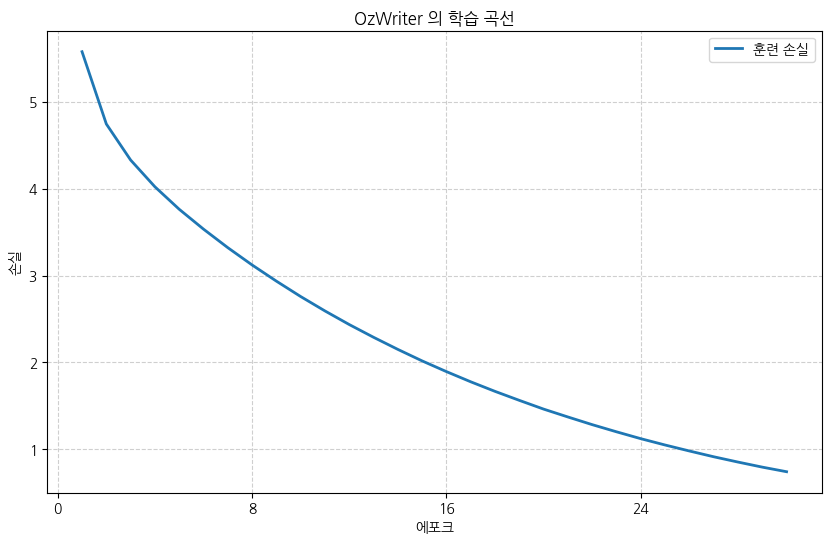

In [12]:
# 참고 - OzWriter 학습 (30 에포크)
EPOCHS = 30
log, results = train(model, dataloader, criterion, optimizer, EPOCHS, 
                     prompt_tokens, vocab, reversed_vocab, device)
log.plot(title='OzWriter 의 학습 곡선')


In [13]:

# 참고 - 임베딩 모델의 생성 결과 출력
print(f'마중물 텍스트: {" ".join(prompt_tokens)}')
for i, generated in enumerate(results):
    if i == 0:
        gen_epoch = 1
    else:
        gen_epoch = i * 5
    print(f'{gen_epoch:2d} 에포크 모델의 생성 결과: {generated}')

마중물 텍스트: dorothy , lion and scarecrow really worried about the emerald city , but oz said the city is safe because
 1 에포크 모델의 생성 결과: , and the scarecrow was a great . the scarecrow , and the scarecrow was a great . the scarecrow , and the scarecrow was a great . the scarecrow
 5 에포크 모델의 생성 결과: i am a good witch , said the scarecrow . i am not , said the scarecrow . i am not , said the scarecrow . i am not ,
10 에포크 모델의 생성 결과: you are a great wizard , and i am sure i am sure i am sure i am sure i am sure i am sure i am sure i am
15 에포크 모델의 생성 결과: you are all wrong . but the scarecrow and the tin woodman and the lion and the lion and the lion and the lion whispered to the throne room and
20 에포크 모델의 생성 결과: you are all wrong , and i’m sure we shall not know what ? we must protect him ourselves if he is a great spring , and then you will
25 에포크 모델의 생성 결과: you are all we can for me . i want him to give me some brains , said the scarecrow . you see , if you will help us to
30 에포크 모델의 생성 결과: yo

위 출력은 [표 7-1] 의 30 에포크 OzWriter 생성 결과에 해당한다. "you are wise . but i thought oz was a terrible beast , said the tin woodman . and i shall never have brains , added the scarecrow ." 처럼 인물(양철나무꾼·허수아비)과 그 욕구(뇌)가 연결된 문장이 이어지는 것을 볼 수 있다. 시드·전처리 차이로 토큰이 달라질 수 있으나, 의미가 호응하는 흐름은 유사하게 관찰된다.

## 참고 - 대조군 OzRawWriter (임베딩 미사용)

본문은 "임베딩 계층의 효과를 확인하기 위한 대조군으로 임베딩 계층이 없는 OzRawWriter 클래스도 만들어 같은 데이터로 학습하는데, OzRawWriter 클래스의 정의 및 학습 과정은 본문에 싣지 않는다" 고 안내한다. 깃허브 노트북 역할인 본 노트북에서는 이를 직접 정의한다.

`OzRawWriter` 는 토큰 고유 번호 대신 원-핫 인코딩된 벡터를 LSTM 에 직접 입력한다. 데이터셋도 원-핫 인코딩 버전인 `OzRawDataset` 으로 새로 만든다.

In [14]:
# 참고 - OzRawDataset(대조군 모델, 임베딩 미사용)
import torch.nn.functional as F

# 임베딩 계층을 사용하지 않는 모델 학습용 데이터셋
#   입력: 원-핫 인코딩된 순차 데이터
#   정답: 고유 번호(교차 엔트로피 손실 함수는 고유 번호를 직접 입력 받음)
class OzRawDataset(Dataset):
    def __init__(self, token_idxs, sequence_length, vocab_size):
        self.token_idxs = token_idxs
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.token_idxs) - self.sequence_length

    def __getitem__(self, idx):
        window = torch.tensor(
            self.token_idxs[idx: idx + self.sequence_length],
            dtype=torch.long,
        )
        x = F.one_hot(window, num_classes=self.vocab_size).float()
        y = torch.tensor(self.token_idxs[idx + self.sequence_length], dtype=torch.long)
        return x, y

# 임베딩 계층이 없이 LSTM 계층, 분류기 계층으로 구성된 순환 신경망 모델
class OzRawWriter(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        # LSTM 의 input_size 는 vocab_size 와 같음
        self.lstm = nn.LSTM(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):                 # 입력 x: (B, S, V) (원-핫 텐서)
        x, _ = self.lstm(x)               #      -> (B, S, hidden_size)
        x = x[:, -1, :]                   #      -> (B, hidden_size)
        return self.fc(x)                 #      -> (B, V)

In [15]:
# 참고 - 모델 학습

# 자기 회귀 방식의 생성 함수: 임베딩이 없어 원-핫 인코딩된 입력을 직접 모델에 전달해 다음 토큰 예측
def make_sentence_raw(model, prompt_tokens, vocab, reversed_vocab,
                      sequence_length, num_generate, device):
    safe_sequence = [t for t in prompt_tokens if t in vocab]
    generated = list(safe_sequence)
    model.eval()
    with torch.no_grad():
        for _ in range(num_generate):
            window = generated[-sequence_length:]
            idxs = torch.tensor(
                [vocab[t] for t in window], dtype=torch.long, device=device,
            )
            # 토큰을 원-핫 인코딩해 모델에 전달, 생성(배치 차원 추가)
            x = F.one_hot(idxs, num_classes=len(vocab)).float().unsqueeze(0)
            logits = model(x)
            next_idx = torch.argmax(logits, dim=1).item()
            generated.append(reversed_vocab[next_idx])
    return generated[len(safe_sequence):]


# # 임베딩 계층이 없는 모델의 학습 함수: make_sentence_raw()를 제외하면 
# def train_raw(model, train_loader, criterion, optimizer, epochs, 
#               prompt_tokens, vocab, reversed_vocab, device=None):
#     generated_results = []
#     if device is None:
#         device = torch.device('cpu')
#     model.to(device)
#     # 학습 로거 생성
#     log = common.EpochLogger(epochs, columns=('훈련 손실',), formats=('{:.4f}',))
#     for epoch in range(1, epochs + 1):
#         # 임베딩 유무와 상관없이 같은 학습 함수를 사용할 수 있음
#         train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
#         # 학습 로그 저장
#         log.row(epoch, train_loss)
#         # 첫 에포크와 5의 배수 에포크마다 마중물 텍스트로 문장 생성
#         if epoch % 5 == 0 or epoch == 1:
#             generated = make_sentence_raw(model, prompt_tokens, vocab, reversed_vocab,
#                                           SEQUENCE_LENGTH, num_generate=30, device=device)
#             generated_results.append(' '.join(generated))
#     return log, generated_results


에포크    훈련 손실     시간
  1/30       5.9163     0:07
  3/30       4.8367     0:20
  6/30       4.0106     0:41
  9/30       3.4468     1:00
 12/30       2.9214     1:21
 15/30       2.4071     1:41
 18/30       1.9275     2:00
 21/30       1.4922     2:20
 24/30       1.1253     2:40
 27/30       0.8233     3:00
 30/30       0.5848     3:20


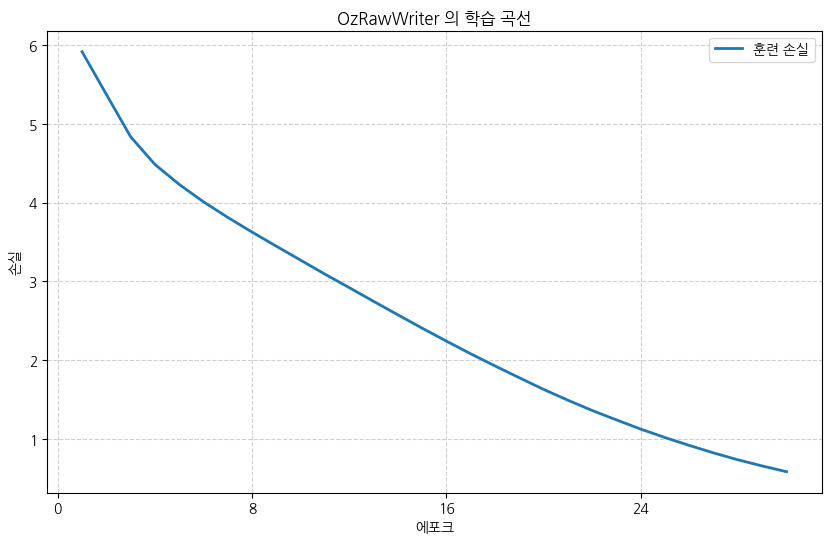

In [17]:
# 참고 - OzRawWriter 학습 (동일 시드로 재현)
common.set_seed()

dataset = OzRawDataset(token_idxs, SEQUENCE_LENGTH, vocab_size)
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
)

model_no_emb = OzRawWriter(vocab_size, HIDDEN_SIZE).to(device)
# 손실 함수는 재사용 가능하지만, 옵티마이저는 모델마다 새로 생성해야 함
optimizer_no_emb = optim.Adam(model_no_emb.parameters(), lr=LR)

log_raw, results_raw = train(model_no_emb, dataloader, criterion, optimizer_no_emb, EPOCHS, 
                            prompt_tokens, vocab, reversed_vocab, device, make_sentence_raw)

log_raw.plot(title='OzRawWriter 의 학습 곡선')

In [18]:
# 참고 - 임베딩 없는 모델의 생성 결과 출력
print(f'마중물 텍스트: {" ".join(prompt_tokens)}')
for i, generated in enumerate(results_raw):
    if i == 0:
        gen_epoch = 1
    else:
        gen_epoch = i * 5
    print(f'{gen_epoch:2d} 에포크 모델의 생성 결과: {generated}')

마중물 텍스트: dorothy , lion and scarecrow really worried about the emerald city , but oz said the city is safe because
 1 에포크 모델의 생성 결과: the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
 5 에포크 모델의 생성 결과: the scarecrow , and i am a heart , and the scarecrow , and the scarecrow and the scarecrow and the scarecrow and the scarecrow and the scarecrow and the
10 에포크 모델의 생성 결과: the lion is a great wizard . i have never been brains , said the scarecrow . i have never been a heart . i will be a heart ,
15 에포크 모델의 생성 결과: the witch is the voice ? i am sure , answered the scarecrow . i am going to give me a heart , said the tin woodman . and i
20 에포크 모델의 생성 결과: the scarecrow is a coward . oh , yes , said the scarecrow . and i am a very kind , you are . there is no use to me
25 에포크 모델의 생성 결과: the great oz will not be well . i’m not afraid , my dear , you are of our , who had been to him . but is no ,
30 에포크 모델의 생성 결과: the queen oz 

## 참고 - 두 모델의 학습 곡선 비교 ([그림 7-7])

본문 [그림 7-7] 은 OzWriter 와 OzRawWriter 의 학습 곡선을 비교한다. 본문 설명대로 초기에는 OzWriter 의 손실이 더 빠르게 떨어지고, 학습 후반(25 에포크 부근)에 이르면 차이가 좁혀지다 OzRawWriter 가 더 낮은 손실에 도달하기도 한다(과적합 신호).

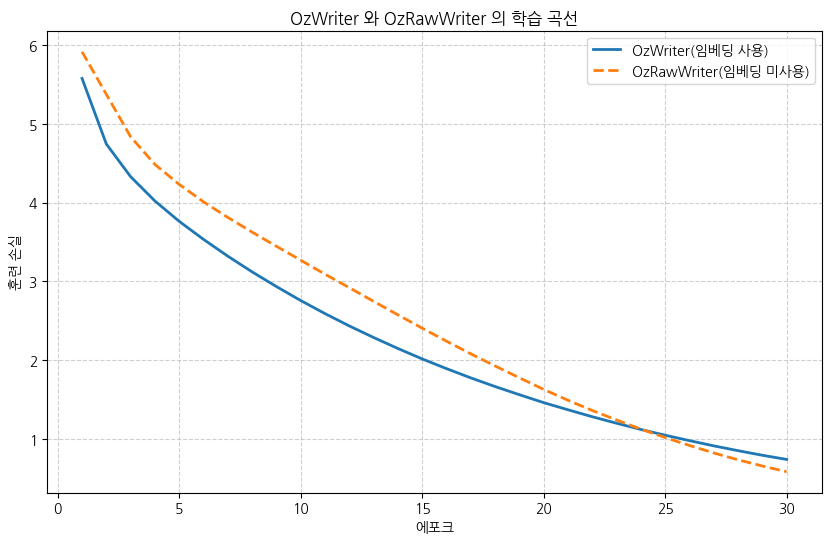

In [19]:
# 참고 - 두 모델의 학습 곡선 비교 ([그림 7-7])
# 각 EpochLogger가 누적한 손실 이력(log.history)을 꺼내 한 그래프로 비교한다.
viz.plot_histories(
    {
        'OzWriter(임베딩 사용)': log.history['훈련 손실'],
        'OzRawWriter(임베딩 미사용)': log_raw.history['훈련 손실'],
    },
    title='OzWriter 와 OzRawWriter 의 학습 곡선',
    y_label='훈련 손실',
)